In [2]:
# ---- Manejo de datos ----
import numpy as np                     # arrays y operaciones numéricas
import pandas as pd                    # DataFrames para tabular
import matplotlib.pyplot as plt        # gráficos

# ---- Datasets ----
#   load_breast_cancer  → dataset de cáncer ya incluido en sklearn
#   make_classification → genera un dataset SINTÉTICO con las propiedades que queramos
#   fetch_openml        → descarga datasets desde el repositorio público OpenML.org
from sklearn.datasets import load_breast_cancer, make_classification, fetch_openml

# ---- Utilidad para dividir en train/test ----
from sklearn.model_selection import train_test_split

# ---- Modelos de clasificación que usaremos ----
from sklearn.linear_model import LogisticRegression       # regresión logística (modelo base)
from sklearn.ensemble import RandomForestClassifier       # bosque aleatorio (para comparar en el reto)
from sklearn.dummy import DummyClassifier                 # modelo "tonto" para baseline

# ---- Pre-procesado ----
from sklearn.preprocessing import StandardScaler          # estandariza features (media=0, std=1)

# ---- Las protagonistas: métricas ----
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,    # las 4 métricas básicas
    confusion_matrix, classification_report,                    # vista global de las métricas
    roc_curve, auc, precision_recall_curve, average_precision_score,  # curvas
    ConfusionMatrixDisplay                                      # plot de la matriz de confusión
)

# ---- Para mostrar imágenes externas ----
from IPython.display import Image, display

# ---- Limpieza visual ----
import warnings; warnings.filterwarnings('ignore')   # silenciamos warnings (no afecta a cálculos)
np.random.seed(42)                                   # semilla global para reproducibilidad

print("Setup OK")

Setup OK


In [3]:
#make_classification genera un dataset sintético con las propiedades que queramos
# n_samples: número de muestras
# n_features: número de características (features)
# weights: proporción de clases (en este caso, 99.8% de clase 0 y 0.2% de clase 1)
# flip_y: porcentaje de etiquetas que se van a invertir (en este caso, 0% para mantener el desequilibrio)

x, y= make_classification(
    n_samples=100_000, n_features=10,
    weights=[0.998, 0.002], flip_y=0 ,random_state=42)


print(f"Total: {len(y)} muestras")
print(f"Clase 0: {np.sum(y == 0)} muestras")
print(f"Clase 1: {np.sum(y == 1)} muestras")
 

Total: 100000 muestras
Clase 0: 99800 muestras
Clase 1: 200 muestras


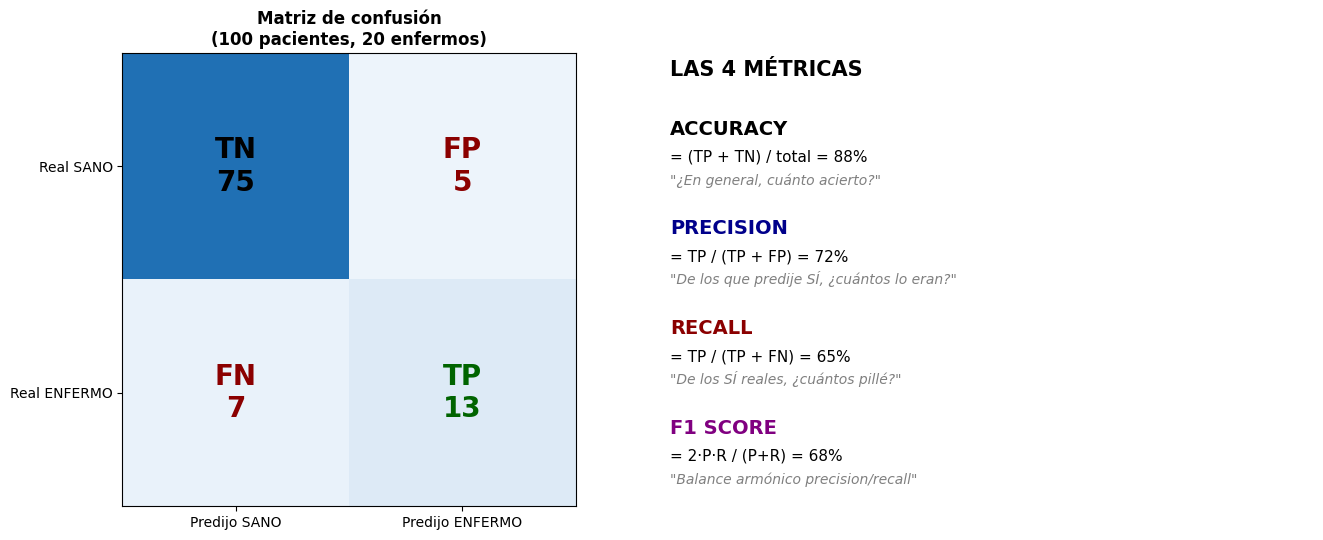

In [ ]:
# Generamos la cheatsheet con matplotlib para que quede dentro del notebook
# plt.subplots(1, 2, ...) crea una figura con 2 subgráficos en una fila.
#   figsize=(ancho, alto) en pulgadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ============== IZQUIERDA: matriz de confusión grande ==============

# np.array([[fila0],[fila1]]) crea una matriz 2×2
# TN=75, FP=5, FN=7, TP=13 (100 pacientes, 20 enfermos); 
# TN: "verdaderos negativos", FP: "falsos positivos", FN: "falsos negativos", TP: "verdaderos positivos"
cm_ej = np.array([[75, 5], [7, 13]])

# Etiquetas de texto para cada casilla (TP/FP/FN/TN + número)
# Atención: \n dentro del string genera salto de línea en la celda
labels = [['TN\n75', 'FP\n5'], ['FN\n7', 'TP\n13']]
colors = [['black', 'darkred'], ['darkred', 'darkgreen']]

ax = axes[0] # panel izquierdo para la matriz de confusión
# imshow pinta una matriz como imagen coloreada
#   cmap='Blues' → escala de azules
#   vmin/vmax    → rango fijo para que el color sea consistente
ax.imshow(cm_ej, cmap='Blues', vmin=0, vmax=100)

# Pintamos las etiquetas en cada celda con ax.text(x, y, texto, ...)
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center',
                fontsize=20, fontweight='bold', color=colors[i][j])

# set_xticks define DÓNDE poner las marcas; set_xticklabels qué texto mostrar
ax.set_xticks([0,1]); ax.set_xticklabels(['Predijo SANO', 'Predijo ENFERMO'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Real SANO', 'Real ENFERMO'])
ax.set_title('Matriz de confusión\n(100 pacientes, 20 enfermos)', fontweight='bold')

# ============== DERECHA: las 4 fórmulas ==============

ax2 = axes[1]
ax2.axis('off')   # quita ejes/marcas en el panel derecho (solo texto)

# ax2.text(x, y, texto, ...) → (x,y) en coordenadas de 0 a 1 dentro del panel
ax2.text(0.02, 0.95, 'LAS 4 MÉTRICAS', fontsize=15, fontweight='bold')

ax2.text(0.02, 0.82, 'ACCURACY', fontsize=14, fontweight='bold')
ax2.text(0.02, 0.76, '= (TP + TN) / total = 88%', fontsize=11)
ax2.text(0.02, 0.71, '"¿En general, cuánto acierto?"', fontsize=10, style='italic', color='gray')

ax2.text(0.02, 0.60, 'PRECISION', fontsize=14, fontweight='bold', color='darkblue')
ax2.text(0.02, 0.54, '= TP / (TP + FP) = 72%', fontsize=11)
ax2.text(0.02, 0.49, '"De los que predije SÍ, ¿cuántos lo eran?"', fontsize=10, style='italic', color='gray')

ax2.text(0.02, 0.38, 'RECALL', fontsize=14, fontweight='bold', color='darkred')
ax2.text(0.02, 0.32, '= TP / (TP + FN) = 65%', fontsize=11)
ax2.text(0.02, 0.27, '"De los SÍ reales, ¿cuántos pillé?"', fontsize=10, style='italic', color='gray')

ax2.text(0.02, 0.16, 'F1 SCORE', fontsize=14, fontweight='bold', color='purple')
ax2.text(0.02, 0.10, '= 2·P·R / (P+R) = 68%', fontsize=11)
ax2.text(0.02, 0.05, '"Balance armónico precision/recall"', fontsize=10, style='italic', color='gray')

plt.tight_layout()    # ajusta márgenes para que no se solapen los textos
plt.show()            # muestra la figura

In [7]:
#import
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

_data = load_breast_cancer()
x_comp= _data.data
y_comp= 1 - _data.target  # invertimos las clases para que la clase positiva sea la minoritaria (cáncer)

#split estratificado para mantener la proporción de clases en train/test
Xc_tr_c, Xc_te_c, yc_tr_c, yc_te_c = train_test_split(
    x_comp, y_comp, test_size=0.3, stratify=y_comp, random_state=42)


_scaler = StandardScaler()  # estandarizador para normalizar las características
Xc_tr_cs = _scaler.fit_transform(Xc_tr_c)  # ajusta el scaler al train y transforma
Xc_te_cs = _scaler.transform(Xc_te_c)      # transforma el test con el mismo scaler

print(f"Train: {Xc_tr_cs.shape}, Test: {Xc_te_cs.shape}")
 

Train: (398, 30), Test: (171, 30)


In [6]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(Xc_tr_cs, yc_tr_c)  # entrenamos el modelo con el train estandarizado
    y_pred = modelo.predict(Xc_te_cs)  # predecimos con el test estandarizado
    
    # Calculamos las métricas básicas
    acc = accuracy_score(yc_te_c, y_pred)
    prec = precision_score(yc_te_c, y_pred)
    rec = recall_score(yc_te_c, y_pred)
    f1 = f1_score(yc_te_c, y_pred)
    
    resultados[nombre] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    print(f"{nombre}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")




 

Logistic Regression: Accuracy=0.9708, Precision=0.9836, Recall=0.9375, F1=0.9600
Random Forest: Accuracy=0.9708, Precision=1.0000, Recall=0.9219, F1=0.9593
KNN: Accuracy=0.9649, Precision=1.0000, Recall=0.9062, F1=0.9508
Decision Tree: Accuracy=0.9064, Precision=0.9615, Recall=0.7812, F1=0.8621


In [6]:
print("Descargamos Spambase de OpenML...")

# fetch_openml descarga el dataset 'spambase' desde OpenML.org
#parser="Auto" es el parser recomendado para evitar problemas de codificación con algunos datasets
spam = fetch_openml('spambase', version=1, as_frame=True, parser="auto")
print("listo!")
 

Descargamos Spambase de OpenML...
listo!


In [9]:
X_spam = spam.data
y_spam = (spam.target.astype(int) == 1).astype(int)  # convertimos a 0/1 (0=ham, 1=spam)

X_spam.head(3)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259


In [10]:
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    X_spam, y_spam, test_size=0.3,
    stratify=y_spam, random_state=42
)

print(f"Train: {len(Xs_tr)} emails")
print(f"Test: {len(Xs_te)} emails")
 

Train: 3220 emails
Test: 1381 emails


In [11]:
model_spam = LogisticRegression(max_iter=2000)


model_spam.fit(Xs_tr, ys_tr)


print("Modelo entrenado con Spambase!")

Modelo entrenado con Spambase!


In [12]:
ys_pred = model_spam.predict(Xs_te)
print("Predicciones realizadas con el modelo de spam!")

#Comparamos predicción vs realidad en las 10 primeras muestras del test
#.values para convertir la serie a array y evitar que se muestre el índice en el DataFrame resultante
pd.DataFrame({
    "Predicción": ys_pred[:10],
    "Valor Real": ys_te.values[:10]
})

Predicciones realizadas con el modelo de spam!


,Predicción,Valor Real
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,0,1
9,0,0


In [13]:
print(classification_report(ys_te, ys_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       837
        Spam       0.92      0.90      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381



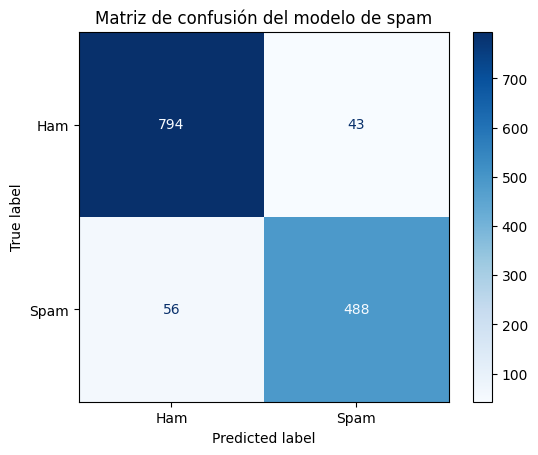

In [14]:
ConfusionMatrixDisplay.from_predictions(ys_te, ys_pred, display_labels=['Ham', 'Spam'], cmap='Blues')
plt.title("Matriz de confusión del modelo de spam")
plt.show()

In [16]:
ys_proba = model_spam.predict_proba(Xs_te)[:, 1]  # probabilidades de la clase positiva (spam)
print("Probabilidades de spam para las primeras 10 muestras del test:")


print(f"{'Umbral':>5} | {'Precision':>9} | {'Recall':>6} | {'FP':>4} | {'FN':>4}")

for threshold in [0.3, 0.5, 0.7, 0.9]:
  pred = (ys_proba >= threshold).astype(int)  # convertimos a 0/1 según el umbral
  p = precision_score(ys_te, pred)
  r = recall_score(ys_te, pred)

  fp = ((pred == 1) & (ys_te == 0)).sum()  # falsos positivos
  fn = ((pred == 0) & (ys_te == 1)).sum()
  # Imprimimos la fila de la tabla:
  #   :>9.3f → 9 caracteres ancho, 3 decimales, formato float
  #   :>4    → 4 caracteres ancho, entero
  print(f"{threshold:>5} | {p:>9.3f} | {r:>6.3f} | {fp:>4} | {fn:>4}")
  

 

Probabilidades de spam para las primeras 10 muestras del test:
Umbral | Precision | Recall |   FP |   FN
  0.3 |     0.850 |  0.949 |   91 |   28
  0.5 |     0.919 |  0.897 |   43 |   56
  0.7 |     0.944 |  0.807 |   26 |  105
  0.9 |     0.976 |  0.599 |    8 |  218


In [17]:
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
X_d = diabetes.data
y_d = (diabetes.target == 'tested_positive').astype(int)   # 1 = diabetes, 0 = sano

print(f"Total: {len(y_d)} pacientes | Diabetes: {y_d.sum()} ({y_d.mean():.1%})")
X_d.head(3)

Total: 768 pacientes | Diabetes: 268 (34.9%)


,preg,plas,pres,skin,insu,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32


In [19]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    X_d, y_d, test_size=0.3,
    stratify=y_d, random_state=42
)

print(f"Train: {len(Xd_tr)} pacientes")
print(f"Test: {len(Xd_te)} pacientes")

Train: 537 pacientes
Test: 231 pacientes


In [20]:
model_diabetes = LogisticRegression(max_iter=2000)


model_diabetes.fit(Xd_tr, yd_tr)


print("Modelo entrenado con Diabetes!")

Modelo entrenado con Diabetes!


In [21]:
yd_pred = model_diabetes.predict(Xd_te)
print("Predicciones realizadas con el modelo de diabetes!")

#Comparamos predicción vs realidad en las 10 primeras muestras del test
#.values para convertir la serie a array y evitar que se muestre el índice en el DataFrame resultante
pd.DataFrame({
    "Predicción": yd_pred[:10],
    "Valor Real": yd_te.values[:10]
})

Predicciones realizadas con el modelo de diabetes!


,Predicción,Valor Real
0,0,1
1,0,1
2,1,1
3,1,1
4,0,1
5,0,0
6,1,0
7,0,0
8,0,0
9,0,0


In [23]:
print(classification_report(yd_te, yd_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.77      0.86      0.81       150
    Diabetes       0.67      0.52      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



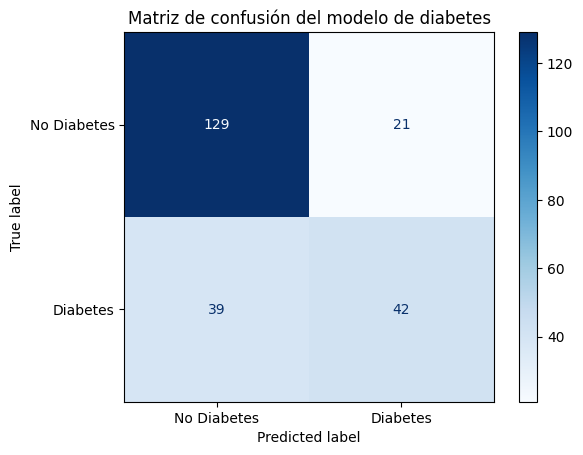

In [24]:
ConfusionMatrixDisplay.from_predictions(yd_te, yd_pred, display_labels=['No Diabetes', 'Diabetes'], cmap='Blues')
plt.title("Matriz de confusión del modelo de diabetes")
plt.show()

In [25]:
modelos_diabetes = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(Xd_tr, yd_tr)  # entrenamos el modelo con el train estandarizado
    y_pred = modelo.predict(Xd_te)  # predecimos con el test estandarizado
    
    # Calculamos las métricas básicas
    acc = accuracy_score(yd_te, y_pred)
    prec = precision_score(yd_te, y_pred)
    rec = recall_score(yd_te, y_pred)
    f1 = f1_score(yd_te, y_pred)
    
    resultados[nombre] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    print(f"{nombre}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

Logistic Regression: Accuracy=0.7403, Precision=0.6667, Recall=0.5185, F1=0.5833
Random Forest: Accuracy=0.7619, Precision=0.7097, Recall=0.5432, F1=0.6154
KNN: Accuracy=0.7186, Precision=0.6212, Recall=0.5062, F1=0.5578
Decision Tree: Accuracy=0.7662, Precision=0.8000, Recall=0.4444, F1=0.5714


In [26]:
cancer = load_breast_cancer()
print("Dataset de cáncer de mama cargado con éxito!")

Dataset de cáncer de mama cargado con éxito!


In [27]:
Xc = cancer.data

yc = 1 - cancer.target

print(f"Total muestras: {len(yc)}")
print(f"Cáncer (maligno, 1): {yc.sum()} ({yc.mean():.1%})")
print(f"Sano (benigno, 0): {len(yc) - yc.sum()} ({1 - yc.mean():.1%})")

Total muestras: 569
Cáncer (maligno, 1): 212 (37.3%)
Sano (benigno, 0): 357 (62.7%)


In [30]:
pd.DataFrame(Xc, columns=cancer.feature_names).iloc[:3, :5]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,17.99,10.38,122.8,1001.0,0.11840
1,20.57,17.77,132.9,1326.0,0.08474
2,19.69,21.25,130.0,1203.0,0.10960


In [31]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.3, stratify=yc, random_state=42
)

model_cancer = LogisticRegression(max_iter=5000).fit(Xc_tr, yc_tr)
print("Modelo de cáncer entrenado con éxito!")

Modelo de cáncer entrenado con éxito!


In [32]:
# .predict() → clase predicha (0 ó 1) con threshold por defecto 0.5
yc_pred = model_cancer.predict(Xc_te)

# .predict_proba()[:, 1] → probabilidad de la clase 1 (cáncer)
# La guardamos porque la usaremos para mover el threshold luego.
yc_proba = model_cancer.predict_proba(Xc_te)[:, 1]

print(f"Primeras 10 predicciones: {yc_pred[:10]}")
print(f"Sus probabilidades:        {yc_proba[:10].round(3)}")

Primeras 10 predicciones: [0 0 0 0 0 0 1 0 0 0]
Sus probabilidades:        [0.289 0.007 0.    0.002 0.01  0.    0.999 0.039 0.395 0.   ]


In [34]:
print(classification_report(yc_te, yc_pred, target_names=["beningno", "cáncer"]))

              precision    recall  f1-score   support

    beningno       0.92      0.99      0.95       107
      cáncer       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



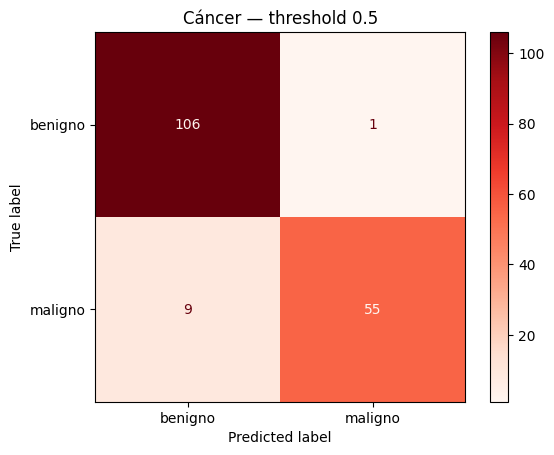


⚠️ Con threshold 0.5 hemos mandado a casa a 9 enfermo(s) de 64


In [35]:
# Visualizamos la matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    yc_te, yc_pred, display_labels=["benigno", "maligno"], cmap="Reds"
)
plt.title("Cáncer — threshold 0.5"); plt.show()

# Contamos los FN (falsos negativos) = pacientes con cáncer enviados a casa
# Máscara: predijo 0 (sano) AND era 1 (cáncer)
fn_default = ((yc_pred == 0) & (yc_te_c == 1)).sum()
print(f"\n⚠️ Con threshold 0.5 hemos mandado a casa a {fn_default} enfermo(s) de {yc_te_c.sum()}")

In [36]:
yc_proba = model_cancer.predict_proba(Xc_te)[:, 1]  # probabilidades de la clase positiva (spam)
print("Probabilidades de cancer para las primeras 10 muestras del test:")


print(f"{'Umbral':>5} | {'Precision':>9} | {'Recall':>6} | {'FP':>4} | {'FN':>4}")

for threshold in [0.3, 0.5, 0.7, 0.9]:
  yc_pred = (yc_proba >= threshold).astype(int)  # convertimos a 0/1 según el umbral
  p = precision_score(yc_te, yc_pred)
  r = recall_score(yc_te, yc_pred)

  fp = ((yc_pred == 1) & (yc_te == 0)).sum()  # falsos positivos
  fn = ((yc_pred == 0) & (yc_te == 1)).sum()
  # Imprimimos la fila de la tabla:
  #   :>9.3f → 9 caracteres ancho, 3 decimales, formato float
  #   :>4    → 4 caracteres ancho, entero
  print(f"{threshold:>5} | {p:>9.3f} | {r:>6.3f} | {fp:>4} | {fn:>4}")

Probabilidades de cancer para las primeras 10 muestras del test:
Umbral | Precision | Recall |   FP |   FN
  0.3 |     0.967 |  0.922 |    2 |    5
  0.5 |     0.982 |  0.859 |    1 |    9
  0.7 |     0.981 |  0.828 |    1 |   11
  0.9 |     1.000 |  0.766 |    0 |   15


In [37]:
# np.arange(start, stop, step) genera valores espaciados regularmente
#   0.99, 0.98, 0.97, ..., 0.01  (step negativo = de mayor a menor)
mejor_thr = None
for thr in np.arange(0.99, 0.0, -0.01):
    # Generamos predicciones aplicando este threshold sobre las probas
    pred = (yc_proba >= thr).astype(int)

    # Cuando el recall llega a 1.0, no hay FN → cogemos ESTE threshold (el más alto que cumple)
    if recall_score(yc_te_c, pred) == 1.0:
        mejor_thr = thr
        break    # salimos del bucle en cuanto encontramos el primero

# Calculamos métricas con el threshold óptimo encontrado
pred_opt = (yc_proba >= mejor_thr).astype(int)
fp = ((pred_opt == 1) & (yc_te_c == 0)).sum()
fn = ((pred_opt == 0) & (yc_te_c == 1)).sum()

print(f"🎯 Threshold más alto con recall=1.0: {mejor_thr:.2f}")
print(f"   Precision: {precision_score(yc_te_c, pred_opt):.2%}")
print(f"   FP (biopsias innecesarias): {fp}")
print(f"   FN (cánceres no detectados): {fn}  ← debe ser 0")
print(f"\n💬 Antes mandábamos a casa a {fn_default} enferm@; ahora ninguno, a cambio de {fp} biopsias extra.")

🎯 Threshold más alto con recall=1.0: 0.04
   Precision: 82.05%
   FP (biopsias innecesarias): 14
   FN (cánceres no detectados): 0  ← debe ser 0

💬 Antes mandábamos a casa a 9 enferm@; ahora ninguno, a cambio de 14 biopsias extra.


In [38]:
modelos_cancer = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

resultados = {}

for nombre, modelo in modelos_cancer.items():
    modelo.fit(Xc_tr, yc_tr)  # entrenamos el modelo con el train estandarizado
    y_pred = modelo.predict(Xc_te)  # predecimos con el test estandarizado
    
    # Calculamos las métricas básicas
    acc = accuracy_score(yc_te, y_pred)
    prec = precision_score(yc_te, y_pred)
    rec = recall_score(yc_te, y_pred)
    f1 = f1_score(yc_te, y_pred)
    
    resultados[nombre] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    print(f"{nombre}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

Logistic Regression: Accuracy=0.9415, Precision=0.9821, Recall=0.8594, F1=0.9167
Random Forest: Accuracy=0.9708, Precision=1.0000, Recall=0.9219, F1=0.9593
KNN: Accuracy=0.9298, Precision=0.9815, Recall=0.8281, F1=0.8983
Decision Tree: Accuracy=0.9064, Precision=0.9615, Recall=0.7812, F1=0.8621


In [43]:
print(classification_report(yc_te, y_pred, target_names=["beningno", "cáncer"]))

              precision    recall  f1-score   support

    beningno       0.88      0.98      0.93       107
      cáncer       0.96      0.78      0.86        64

    accuracy                           0.91       171
   macro avg       0.92      0.88      0.90       171
weighted avg       0.91      0.91      0.90       171



| Modelo | Cómo funciona | Tipo de datos idóneo | Cuándo brilla | Cuándo NO usar |
|---|---|---|---|---|
| **LogisticRegression** | Frontera lineal entre clases | Numérico, features independientes | Dataset tabular, relación lineal o casi, **interpretabilidad** | Relaciones muy no lineales |
| **KNN** | "Te clasifico como tus K vecinos más parecidos" | Numérico, **misma escala** (¡estandarizar!) | Datasets pequeños, fronteras irregulares | Muchas features (curse of dimensionality), datasets grandes |
| **DecisionTree** | Encadena preguntas tipo "¿edad > 30?" | Numérico **y/o** categórico mezclado | Reglas explicables, no requiere escalar | Overfittea fácilmente si no se poda |
| **RandomForest** | Promedia 100+ árboles de decisión | Tabular en general, mixto numérico/categórico | "Modelo por defecto" para tabular. Robusto sin tunear. | Cuando necesitas **explicar** la decisión (es caja negra) |
| **SVM** | Busca el "margen máximo" entre clases | Numérico estandarizado, **muchas features** | Texto (bag-of-words), datasets medianos con alta dimensión | Datasets grandes (>50k filas → lento) |
| **GradientBoosting / XGBoost** | Suma árboles, cada uno corrige al anterior | Tabular, mixto | Suele ganar competiciones Kaggle. Top en tabular. | Cuando no te puedes permitir tunear hiperparámetros |
| **NaïveBayes** | Probabilidades suponiendo features independientes | Texto (frecuencia de palabras) | Spam, clasificación de texto, rápido y simple | Cuando las features están muy correlacionadas |